# EDA — `papers_benchset_v1.parquet`, 28 collections at realistic prevalence

**Scope:** read-only exploratory analysis. Nothing is written back to `data/`.

## What this notebook is

The full EDA pass on `data/processed/papers_benchset_v1.parquet` — 181,199 papers across
28 published systematic-review screening collections, built and verified by
`01_data_compile_benchset_v1.ipynb`. It is the benchmark-corpus counterpart to
`03_eda_full.ipynb`, and it deliberately does **not** mirror that notebook section for
section, because four differences make a mechanical port wrong rather than merely
incomplete.

**1. Prevalence is 1.86%, not 37%.** `03_eda_full.ipynb` works on a corpus where a
coin-flip baseline is a reasonable reference point. Here, "not relevant" every time scores
98.14%. Accuracy is never reported below. The metrics are the screening ones —
ROC-AUC, Recall@k, and WSS@95 (`fold_pipeline_utils.ranking_metrics`, the same definition
the rest of the repo uses).

**2. Pooling is forbidden, not merely unwise.** `CONTEXT.md` §1: use cases are
per-customer and siloed, no pooled model ever ships, and within-silo is the production
surface. The corpus README says the same thing from the data side. So **every
label-conditional statistic in this notebook is computed per collection**, and pooled
figures appear only where a corpus-level fact is genuinely what's being described. Per
`CONTEXT.md` §5, per-collection results are reported with **win counts beside means**,
and `roadfreight_metareview` — 78% positive, 132 rows, and a review-of-reviews rather
than a screening task — is excluded from every headline average.

**3. Two classes, no `pass`, no nulls.** §2.3 and §2.4 of `03_eda_full.ipynb` establish
that `pass` is a missing-abstract artefact and resolve to binarize the target. There is
nothing to resolve here: this corpus ships `positive`/`negative` with 100% coverage. That
section is replaced by the question this corpus actually raises — what the prevalence
spread does to what can be measured at all.

**4. It ships no embeddings.** They are computed by `scripts/embed_benchsets.py`
(Jasper-600M + Qwen3-Embedding-4B, the pairing `reports/wf_embedding_bakeoff.md` §8
adopted) and joined from `embeddings_cache/` at read time. **Run that script before this
notebook.**

## What is deliberately not here

- **Leave-one-collection-out.** Cross-silo generalisation is a defaults-selection
  experiment (`CONTEXT.md` §1), not EDA, and the collapse it measures is already
  established: `05_validation_design.ipynb` finds mean held-out AUC 0.50–0.54 across all
  six TIRI questions, and `CONTEXT.md` §2 records LOGO at ~0.54. Re-running it across 28
  collections is a real experiment deserving its own notebook, and §14 says so rather
  than leaving the omission unexplained.
- **High-dimensional embedding arms in the model comparison.** §13 uses the ~30 scalar
  features plus one raw-embedding arm for contrast, not the full ablation — that lives in
  `09_ensemble_per_silo.ipynb` and `reports/wf_ensemble_v2_experiments.md`.

Findings are labelled **hard finding** (a computed number) or **judgement call** (an
interpretation), following this repo's convention that a metric and a reading of it are
never presented as the same kind of claim.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

sys.path.insert(0, "../../scripts")
from fold_pipeline_utils import derive_first_author, ranking_metrics  # noqa: E402
from lexical_features import build_lexical_features  # noqa: E402

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_PATH = Path("../../data/processed/papers_benchset_v1.parquet")
CACHE_DIR = Path("../../data/processed/embeddings_cache")

EMBEDDING_MODELS = {
    "jasper": "infgrad__Jasper-Token-Compression-600M",
    "qwen4b": "Qwen__Qwen3-Embedding-4B",
}
EXCLUDE_FROM_HEADLINE = "roadfreight_metareview"
MIN_POSITIVES_TO_SPLIT = 40
N_SPLITS = 5

df = pd.read_parquet(DATA_PATH)
prevalence = df.groupby("use_case_key", observed=True)["label_positive"].mean()
UC_ORDER = list(prevalence.sort_values().index)

print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns from {DATA_PATH}")
print(f"{len(UC_ORDER)} collections | pooled prevalence {df['label_positive'].mean():.2%}")

Loaded 181,199 rows, 24 columns from ../../data/processed/papers_benchset_v1.parquet
28 collections | pooled prevalence 1.86%


## 1. Shape and structure

24 columns in five groups: identity (`row_key`, `paper_id`, `use_case_key`),
bibliographic metadata (`title`, `authors`, `year`, `doi`, `citation_count`), the
screening decision (`triage_label`, `label_positive`), paper text (`abstract`,
`has_abstract`), and the research question's brief (`objective`, `problem_statement`,
`terms_*`, `domain_*`) broadcast onto every row of its collection.

29 of `papers_combined.parquet`'s 50 columns are absent — `embedding`,
`relevance_score`, `venue`, `language`, `from_*`, `review_label`, `trl_*` and the rest.
That is a published contract (`manifest.json`'s `excluded_on_purpose`), not a gap;
`01_data_compile_benchset_v1.ipynb` §8 prints it in the corpus's own words.

In [2]:
df.dtypes.to_frame("dtype")

,dtype
row_key,str
paper_id,str
use_case_key,str
title,str
abstract,str
triage_label,category
authors,str
doi,str
year,Int64
citation_count,Int64


In [3]:
df[["row_key", "use_case_key", "title", "year", "citation_count", "triage_label"]].head()

,row_key,use_case_key,title,year,citation_count,triage_label
0,nykvist_evcharging__title:1e6e919222966f883646...,nykvist_evcharging,Traction control-integrated energy management ...,2017,8,negative
1,nykvist_evcharging__title:1241ca599a26488d955b...,nykvist_evcharging,Environmental sustainability policy on plug-in...,2020,6,negative
2,nykvist_evcharging__title:1cbf93b3bc4f009a0b10...,nykvist_evcharging,Energy management of plug-in hybrid electric v...,2020,19,negative
3,nykvist_evcharging__title:3efa44a39ebc9c456fdc...,nykvist_evcharging,Probabilistic Harmonic Analysis for Waveform D...,2019,3,negative
4,nykvist_evcharging__title:0af5f418b673b13a3aa8...,nykvist_evcharging,Day-Ahead Optimal Management of Plug-in Hybrid...,2021,5,negative


## 2. The target: prevalence is the story

`03_eda_full.ipynb` spends §2.1–2.4 on class balance and on whether `pass` is a real
third class. Neither question exists here. What replaces them is the question this corpus
forces: **the collections are so different from each other that "how imbalanced is the
data" has no single answer.**

### 2.1 Prevalence per collection — hard finding

In [4]:
target = pd.DataFrame({
    "n_papers": df.groupby("use_case_key", observed=True).size(),
    "positive": df.groupby("use_case_key", observed=True)["label_positive"].sum(),
}).reindex(UC_ORDER)
target["prevalence"] = target["positive"] / target["n_papers"]
target["too_small_to_split"] = target["positive"] < MIN_POSITIVES_TO_SPLIT

print(f"Pooled: {int(target['positive'].sum()):,} positive of {int(target['n_papers'].sum()):,} "
      f"({target['positive'].sum() / target['n_papers'].sum():.2%})")
print(f"Per collection: {target['prevalence'].min():.2%} to {target['prevalence'].max():.2%}, "
      f"median {target['prevalence'].median():.2%}\n")
target.style.format({"prevalence": "{:.2%}"})

Pooled: 3,374 positive of 181,199 (1.86%)
Per collection: 0.16% to 78.03%, median 1.62%



,n_papers,positive,prevalence,too_small_to_split
use_case_key,,,,
synergy_brouwer_2019,38114,62,0.16%,False
synergy_bos_2018,4877,10,0.21%,True
synergy_leenaars_2019,5812,17,0.29%,True
synergy_wolters_2018,4278,19,0.44%,True
synergy_chou_2004,1630,9,0.55%,True
synergy_chou_2003,1907,15,0.79%,True
synergy_van_dis_2020,9128,72,0.79%,False
synergy_radjenovic_2013,5935,48,0.81%,False
synergy_van_de_schoot_2018,4544,38,0.84%,True


**Hard finding:** prevalence spans **0.16%** (`synergy_brouwer_2019`: 62 relevant papers
in 38,114) to **78.03%** (`roadfreight_metareview`: 103 in 132) — a ~480× spread. The
pooled 1.86% describes no collection in the corpus; the median collection sits at ~1.7%,
and eight run above 7%.

**Judgement call:** report per-collection results with win counts, never a bare mean over
28. A mean here is dominated by whichever collections happen to be easy, and
`CONTEXT.md` §5 already records that this repo has made at least one decision on that
kind of noise. `roadfreight_metareview` is excluded from headline averages throughout —
not because it is inconvenient, but because it selects *review papers* rather than
individual studies and is a different task.

### 2.2 What the spread costs: 12 collections cannot be split — hard finding

In [5]:
n_small = int(target["too_small_to_split"].sum())
splittable = [uc for uc in UC_ORDER if not target.loc[uc, "too_small_to_split"]]

print(f"{n_small} of {len(UC_ORDER)} collections have < {MIN_POSITIVES_TO_SPLIT} positives:")
print(target.loc[target["too_small_to_split"], ["n_papers", "positive"]]
      .sort_values("positive").to_string())
print(f"\nWith {N_SPLITS}-fold CV, the smallest of these would put "
      f"{target.loc[target['too_small_to_split'], 'positive'].min() / N_SPLITS:.1f} positives "
      "in a validation fold.")
print(f"\n{len(splittable)} collections are usable for within-collection train/test.")

12 of 28 collections have < 40 positives:
                                 n_papers  positive
use_case_key                                       
synergy_chou_2004                    1630         9
synergy_bos_2018                     4877        10
synergy_chou_2003                    1907        15
synergy_donners_2021                  258        15
synergy_leenaars_2019                5812        17
synergy_wolters_2018                 4278        19
synergy_oud_2018                      952        20
synergy_appenzeller-herzog_2019      2841        26
synergy_smid_2020                    2627        27
synergy_van_der_waal_2022            1970        33
synergy_meijboom_2021                 882        37
synergy_van_de_schoot_2018           4544        38

With 5-fold CV, the smallest of these would put 1.8 positives in a validation fold.

16 collections are usable for within-collection train/test.


**Hard finding:** 12 of 28 collections carry fewer than 40 positives — as few as **9**
(`synergy_chou_2004`). At 5-fold CV that is under 2 positives per validation fold, where
a single paper moves ROC-AUC by a visible amount and WSS@95 is essentially undefined.

**Judgement call:** these 12 are **evaluation-only** surfaces — usable for scoring a
ranker built elsewhere (cosine-to-brief needs no labels at all), not for training and
testing inside. §13's model comparison runs on the other 16 and says so. This is the
corpus README's third warning, re-derived here rather than quoted.

## 3. Missing data

**Convention, from the root `CONTRIBUTING.md`: NULL is not 0.** Nothing below is filled.

The one carried-over assumption that must be re-checked rather than inherited: in
`papers_combined.parquet` a missing abstract is an **empty string**, so `.isna()` reports
zero and `03_eda_full.ipynb` §8.1 uses the `has_abstract` flag instead. In this corpus it
is a genuine **NULL**. `01_data_compile_benchset_v1.ipynb` §6 asserts which convention
holds; this section just reports the consequences.

In [6]:
missing = df.isna().sum()
missing_table = pd.DataFrame({
    "n_missing": missing,
    "pct_missing": (missing / len(df) * 100).round(2),
})
missing_table[missing_table["n_missing"] > 0].sort_values("n_missing", ascending=False)

,n_missing,pct_missing
authors,19210,10.60
citation_count,18599,10.26
doi,18218,10.05
year,16995,9.38
abstract,4733,2.61


In [7]:
by_label = df.groupby("triage_label", observed=True).agg(
    pct_no_abstract=("has_abstract", lambda s: (~s).mean() * 100),
    pct_no_citations=("citation_count", lambda s: s.isna().mean() * 100),
    pct_no_year=("year", lambda s: s.isna().mean() * 100),
    pct_no_authors=("authors", lambda s: s.isna().mean() * 100),
).round(2)

by_collection = (1 - df.groupby("use_case_key", observed=True)["has_abstract"].mean()).reindex(UC_ORDER)

print("Missingness by label (pooled across collections):")
print(by_label.to_string())
print(f"\nAbstract-missing rate by collection: {by_collection.min():.1%} to "
      f"{by_collection.max():.1%} (worst: {by_collection.idxmax()})")
print(by_collection.mul(100).round(1).sort_values(ascending=False).head(6).to_string())

Missingness by label (pooled across collections):
              pct_no_abstract  pct_no_citations  pct_no_year  pct_no_authors
triage_label                                                                
positive                 3.08              9.31         8.24            9.43
negative                 2.60             10.28          9.4           10.62

Abstract-missing rate by collection: 0.0% to 23.2% (worst: synergy_appenzeller-herzog_2019)
use_case_key
synergy_appenzeller-herzog_2019    23.2
synergy_chou_2004                  11.6
synergy_wolters_2018                8.9
synergy_meijboom_2021               6.6
roadfreight_metareview              6.1
synergy_chou_2003                   5.7


**Hard finding:** missingness is nearly flat across labels — relevant and not-relevant
papers differ by roughly a percentage point on abstract, citation, year and author
coverage. That is a meaningful negative result, because it is the *opposite* of the TIRI
corpus, where `pass` papers are 84.7% missing-abstract and label correlates strongly with
metadata completeness (`CONTEXT.md` §3).

**Judgement call:** the reason is structural and worth stating, because it changes what
this corpus can be used for. These labels come from published systematic reviews, where
every record in the search result was screened by a human. There is no triage queue, so
there is no "I skipped this because there was nothing to read" class. **A completeness
feature that works on the TIRI corpus should not be expected to work here**, and if one
does, that is evidence it was measuring the labelling process rather than relevance.

**Hard finding:** abstract coverage varies far more *between* collections (0% to 23.2%
missing) than between labels. Any text feature is title-only for those rows, and a
collection with 23% missing abstracts is a materially harder screening problem than one
with 0% — a per-collection property, invisible in any pooled view.

## 4. Duplicates, integrity, and the same paper judged two ways

Two cheap checks, then the one that matters.

In [8]:
n_rows = len(df)
print(f"Rows: {n_rows:,} | unique row_key: {df['row_key'].nunique():,} -> "
      f"{'OK' if df['row_key'].is_unique else 'MISMATCH'}")
print(f"Distinct paper_id: {df['paper_id'].nunique():,} "
      f"({n_rows - df['paper_id'].nunique():,} rows share a paper_id with another row)")

within = df.duplicated(subset=["use_case_key", "paper_id"]).sum()
print(f"Repeats WITHIN a collection: {within} (the manifest's row_key contract says 0)")

df["_norm_title"] = df["title"].str.strip().str.lower()
dup_mask = df.duplicated(subset=["use_case_key", "_norm_title"], keep=False)
dup = df[dup_mask]
groups = dup.groupby(["use_case_key", "_norm_title"])
print(f"Rows sharing a normalised title WITHIN a collection: {len(dup):,} "
      f"in {groups.ngroups:,} groups")

# Not all of these are duplicate papers. Some source records carry a placeholder where
# the title should be ("Title", "CE", "Orals"), which collapses unrelated papers into one
# group and would overstate the problem if counted as duplicates.
title_len = dup["_norm_title"].str.split().str.len()
real = dup[title_len >= 5]
real_groups = real.groupby(["use_case_key", "_norm_title"])
placeholder_groups = groups.ngroups - real_groups.ngroups

print(f"  of which look like real titles (>= 5 words): {len(real):,} rows in "
      f"{real_groups.ngroups:,} groups")
print(f"  short/placeholder titles ('Title', 'CE', 'Orals'...): {placeholder_groups} groups")
print(f"\nReal-title duplicate groups whose rows DISAGREE on the label: "
      f"{int((real_groups['label_positive'].nunique() > 1).sum())}")
print(f"Rows in a real-title duplicate group that still carry distinct DOIs: "
      f"{int(real.groupby(['use_case_key', '_norm_title'])['doi'].nunique().sum()):,}")
print("\nCollections most affected:")
print(real.groupby("use_case_key", observed=True).size().nlargest(5).to_string())
df.drop(columns="_norm_title", inplace=True)

Rows: 181,199 | unique row_key: 181,199 -> OK


Distinct paper_id: 177,995 (3,204 rows share a paper_id with another row)


Repeats WITHIN a collection: 0 (the manifest's row_key contract says 0)


Rows sharing a normalised title WITHIN a collection: 1,785 in 550 groups
  of which look like real titles (>= 5 words): 565 rows in 273 groups
  short/placeholder titles ('Title', 'CE', 'Orals'...): 277 groups

Real-title duplicate groups whose rows DISAGREE on the label: 7
Rows in a real-title duplicate group that still carry distinct DOIs: 562

Collections most affected:
use_case_key
synergy_hall_2012          136
synergy_radjenovic_2013     86
synergy_brouwer_2019        77
synergy_leenaars_2020       70
synergy_walker_2018         67


In [9]:
per_paper = df.groupby("paper_id")["use_case_key"].nunique()
shared_ids = per_paper[per_paper > 1].index
shared = df[df["paper_id"].isin(shared_ids)]

label_variety = shared.groupby("paper_id")["label_positive"].nunique()
conflicted = label_variety[label_variety > 1].index

print(f"Papers screened under more than one question: {len(shared_ids):,}")
print(f"  ...labelled BOTH relevant and not relevant, depending on the question: "
      f"{len(conflicted):,} ({len(conflicted) / len(shared_ids):.1%} of shared papers)")
print(f"  ...consistent across questions: {len(shared_ids) - len(conflicted):,}")
print(f"\nRows involved in a conflicted pair: {int(df['paper_id'].isin(conflicted).sum()):,}")

pair_counts = (
    shared[shared["paper_id"].isin(conflicted)]
    .groupby("use_case_key", observed=True).size()
    .sort_values(ascending=False)
)
print("\nWhich collections contribute conflicted rows (top 8):")
print(pair_counts.head(8).to_string())

Papers screened under more than one question: 3,137
  ...labelled BOTH relevant and not relevant, depending on the question: 130 (4.1% of shared papers)
  ...consistent across questions: 3,007

Rows involved in a conflicted pair: 265

Which collections contribute conflicted rows (top 8):
use_case_key
synergy_radjenovic_2013       65
synergy_hall_2012             65
synergy_walker_2018           24
synergy_brouwer_2019          22
synergy_van_dis_2020          19
synergy_wassenaar_2017        16
synergy_van_de_schoot_2018    11
synergy_oud_2018               7


**Hard finding — a within-collection duplicate the corpus's own dedupe does not catch.**
`row_key` is unique and there are no repeated `paper_id`s inside a collection, so the
manifest's contract holds exactly as stated. But `paper_id` is `doi:<lowered>` where a DOI
exists, so **two records of the same paper under two different DOIs are two distinct
`paper_id`s** and survive deduplication. Several hundred groups of rows share a real
(≥5-word) title inside one collection, and nearly all of them carry distinct DOIs.

**Judgement call:** this is a genuine leakage channel for within-collection folds — the
production fold design — and it is not covered by grouping on first author, since a
duplicated paper shares its author too only if the author field parsed identically.
Grouping folds on normalised title alongside first author would close it. The effect is
small (well under 1% of rows) and the label almost always agrees between copies, so this
is a correctness note for whoever builds the modelling split, not a reason to distrust the
numbers below. It is flagged here because it is invisible in the manifest, which reports
its dedupe as complete — and by its own definition it is.

Note also that a minority of these groups are not duplicates at all: some source records
carry a placeholder where the title should be (`"Title"`, `"CE"`, `"Orals"`), which
collapses unrelated papers together. The cell separates the two rather than reporting one
inflated count.

**Hard finding — the same paper, two questions, two different answers.** **3,137 papers
were screened under more than one question, and 130 of them are `positive` under one
question and `negative` under another.** Same paper, same title and abstract, judged by the
domain experts who ran each review, coming out differently because the question changed.

**Judgement call, and the calibration matters:** this is a **direct demonstration on
external data** that relevance is a property of the (brief, paper) pair — `CONTEXT.md`
§2's central finding, which until now rested on indirect evidence (a classifier recovering
`use_case_key` from an embedding at 96.2%, LOGO collapsing to ~0.54, brief-relative
features beating paper-only ones). It is **not** a measurement of the effect's size:
96% of shared papers *are* labelled consistently, which is what you would expect when two
reviews that both surface a paper are usually topically adjacent. The size estimate stays
where `CONTEXT.md` §2 puts it.

**The operational consequence is the durable part.** These 130 papers are a leakage
channel with no analogue in the TIRI corpus, and they cut both ways:

- **Never deduplicate on `paper_id` across collections.** It would delete real,
  independently-labelled rows and silently pick a winner between two correct answers —
  the mistake `04_feature_engineering.ipynb` §3 already guards against by scoping its
  dedupe within `use_case_key`.
- **Any pooled split leaks.** The same paper's text would sit in train for one collection
  and test for another, with a label the model has already seen. Within-collection folds
  — which `CONTEXT.md` §1 requires anyway — make this moot, which is a second, independent
  argument for the same fold design.

## 5. Univariate analysis — numeric columns

Only `year` and `citation_count` survive into this corpus; `relevance_score` and
`trl_min`/`trl_max` are among the columns the manifest drops. That is no loss:
`CONTEXT.md` §6 already rejects `relevance_score` as a feature or baseline (unversioned,
moving, not comparable across use cases).

           year  citation_count
count  164204.0        162600.0
mean    2006.69           81.55
std        9.89          580.85
min      1846.0             0.0
25%      2002.0            12.0
50%      2008.0            32.0
75%      2013.0            75.0
max      2025.0        110293.0

                skewness
year               -1.47
citation_count     100.6


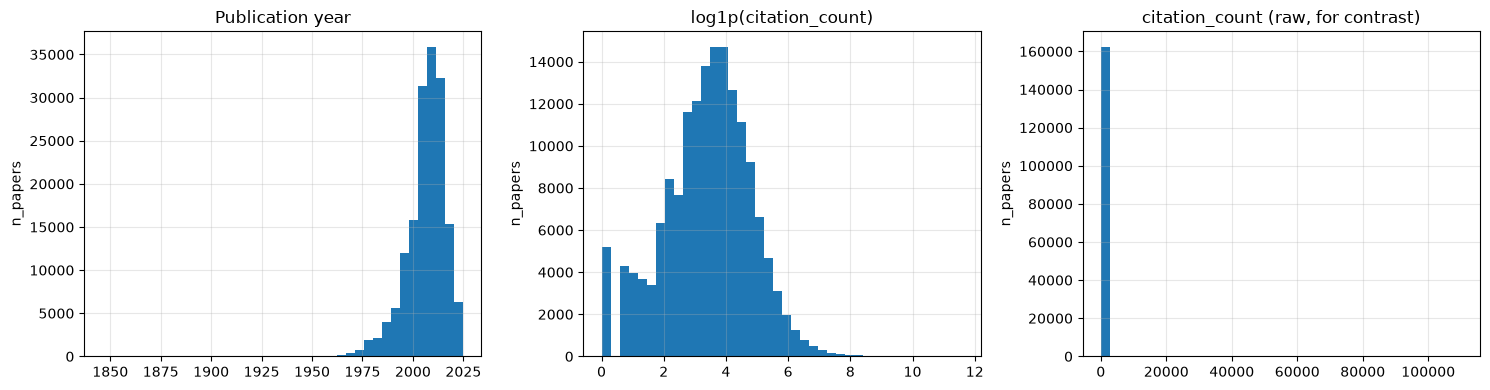

In [10]:
print(df[["year", "citation_count"]].describe().round(2).to_string())
print()
print(df[["year", "citation_count"]].skew(numeric_only=True).round(2).to_frame("skewness").to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["year"].dropna().plot(kind="hist", bins=40, ax=axes[0], title="Publication year")
np.log1p(df["citation_count"].dropna()).plot(kind="hist", bins=40, ax=axes[1],
                                             title="log1p(citation_count)")
df["citation_count"].dropna().plot(kind="hist", bins=40, ax=axes[2],
                                   title="citation_count (raw, for contrast)")
for ax in axes:
    ax.set_ylabel("n_papers")
plt.tight_layout()
plt.show()

**Hard finding:** `citation_count` is extremely right-skewed (skewness in the double
digits) — the raw histogram is a single bar with an invisible tail thousands of citations
long, while `log1p` is roughly unimodal and workable. `year` is left-skewed toward recent
work but spans a much wider range than the TIRI corpus, because these reviews were run
across several decades rather than in 2024–2026.

**Judgement call:** use `log1p(citation_count)` for any plot or model, never the raw
count — the same conclusion `03_eda_full.ipynb` §5.1 reaches, and it transfers unchanged.

## 6. Univariate analysis — categorical columns

### 6.1 `use_case_key` — hard finding

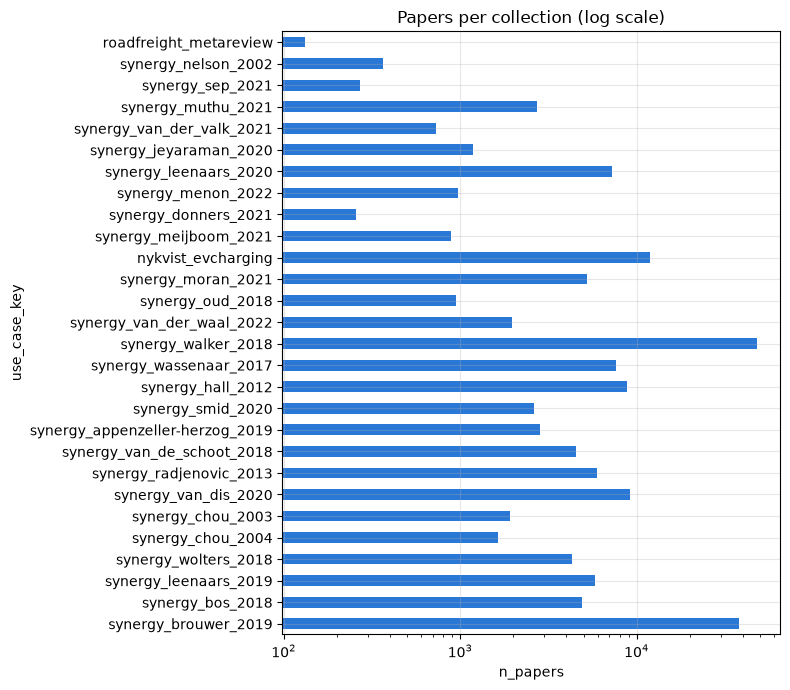

Smallest: 132 (roadfreight_metareview)
Largest:  48,343 (synergy_walker_2018)
Ratio: 366x  (the TIRI corpus's equivalent spread is 2.4x)

The two largest collections are 48% of all rows.


In [11]:
counts = df["use_case_key"].value_counts().reindex(UC_ORDER)
fig, ax = plt.subplots(figsize=(8, 7))
counts.plot(kind="barh", ax=ax, title="Papers per collection (log scale)", color="#2a78d6")
ax.set_xscale("log")
ax.set_xlabel("n_papers")
plt.tight_layout()
plt.show()

print(f"Smallest: {counts.min():,} ({counts.idxmin()})")
print(f"Largest:  {counts.max():,} ({counts.idxmax()})")
print(f"Ratio: {counts.max() / counts.min():.0f}x  "
      f"(the TIRI corpus's equivalent spread is 2.4x)")
print(f"\nThe two largest collections are {counts.nlargest(2).sum() / counts.sum():.0%} "
      "of all rows.")

**Hard finding:** collections range from 132 to 48,343 papers — a **366× spread**, versus
2.4× in the TIRI corpus. The two largest (`synergy_walker_2018`, `synergy_brouwer_2019`)
are 48% of all rows on their own.

**Judgement call:** this is a second, independent reason never to pool. Even setting aside
the topical argument, a pooled model would be half-trained on two medical reviews. It also
means any corpus-wide average is really a weighted average dominated by two collections —
so §13 reports per-collection results and win counts.

### 6.2 Brief columns are constant within a collection — hard finding

In [12]:
BRIEF_COLS = ["use_case_name", "objective", "problem_statement", "domain_industry",
              "domain_application", "domain_technology_focus", "terms_must_include",
              "terms_nice_to_have", "terms_exclude", "brief_provenance"]


def nunique_safe(s):
    if s.apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        s = s.apply(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)
    return s.nunique(dropna=False)


within_uc = df.groupby("use_case_key", observed=True)[BRIEF_COLS].apply(
    lambda g: pd.Series({c: nunique_safe(g[c]) for c in BRIEF_COLS})
)
print("Distinct values within each collection (should be 1 for every cell):")
print(f"  max over all collections x columns: {int(within_uc.to_numpy().max())}")
print(f"  min: {int(within_uc.to_numpy().min())}")

empty_terms = {
    c: int(sum(len(df.loc[df['use_case_key'] == uc, c].iloc[0]) == 0 for uc in UC_ORDER))
    for c in ["terms_must_include", "terms_nice_to_have", "terms_exclude"]
}
print(f"\nCollections whose term list is EMPTY (not zero — 'not specified'): {empty_terms}")

Distinct values within each collection (should be 1 for every cell):
  max over all collections x columns: 1
  min: 1

Collections whose term list is EMPTY (not zero — 'not specified'): {'terms_must_include': 0, 'terms_nice_to_have': 0, 'terms_exclude': 0}


**Hard finding, confirmed rather than assumed:** every brief column has exactly one
distinct value within every collection. They encode "which question is this", redundantly
with `use_case_key`, not anything about the individual paper.

**Judgement call:** `domain_industry` / `domain_application` / `domain_technology_focus`
are not usable as per-paper model features — one-hotting them alongside `use_case_key`
re-weights the same 28-way signal twice. They *are* usable as **inputs to a
brief-relative feature**, which is the entire point of `scripts/lexical_features.py`:
the brief is not a feature, it is the thing a feature is computed *against*. That
distinction is what `CONTEXT.md` §2 is about, and it is why the same columns that are
useless one way are load-bearing the other.

Note also that unlike the TIRI corpus — where `terms_exclude` is empty for 3 of 6 use
cases and `constraints_scale` is empty everywhere — every collection here carries a
populated `terms_must_include`, `terms_nice_to_have` and `terms_exclude`. These briefs
were LLM-drafted to a fixed schema, so they are *more* uniformly populated than the
hand-written ones, while being less authoritative. Both facts matter when reading §8.

## 7. Bivariate analysis — metadata vs. the target, per collection

`03_eda_full.ipynb` §7.1 tests whether `citation_count` and `citation_velocity` differ
between relevant and not-relevant papers, using a Mann-Whitney U test (chosen over a
t-test because both columns are far too skewed for the normality assumption). It finds no
significant difference and *revises* an earlier eyeballed claim on that basis.

Here the same test is run **28 times, once per collection**, because a pooled test would
be answering a question about a corpus nobody will ever train on. That raises multiple
comparisons, so p-values are corrected (Benjamini–Hochberg, controlling false discovery
rate — the appropriate choice when the question is "how many of these are real", not
"is this one specific one real").

In [13]:
df["paper_age"] = (pd.to_datetime(df["exported_at"]).dt.year - df["year"]).clip(lower=0)
df["citation_velocity"] = df["citation_count"] / (df["paper_age"].astype("float") + 1)

rows = []
for uc in UC_ORDER:
    sub = df[df["use_case_key"] == uc]
    row = {"use_case_key": uc, "prevalence": float(sub["label_positive"].mean())}
    for col in ["citation_count", "citation_velocity"]:
        pos = sub.loc[sub["label_positive"] == 1, col].dropna()
        neg = sub.loc[sub["label_positive"] == 0, col].dropna()
        if len(pos) < 3 or len(neg) < 3:
            row[f"{col}_p"], row[f"{col}_r"] = np.nan, np.nan
            continue
        u, p = stats.mannwhitneyu(pos, neg, alternative="two-sided")
        row[f"{col}_p"] = float(p)
        # Rank-biserial correlation: +1 = positives always rank higher, 0 = no separation.
        row[f"{col}_r"] = float(1 - (2 * u) / (len(pos) * len(neg)))
    rows.append(row)
bivariate = pd.DataFrame(rows).set_index("use_case_key")


def benjamini_hochberg(pvals):
    p = np.asarray(pvals, dtype=float)
    ok = ~np.isnan(p)
    out = np.full_like(p, np.nan)
    ranked = stats.false_discovery_control(p[ok], method="bh")
    out[ok] = ranked
    return out


for col in ["citation_count", "citation_velocity"]:
    bivariate[f"{col}_q"] = benjamini_hochberg(bivariate[f"{col}_p"])

headline = bivariate.drop(index=EXCLUDE_FROM_HEADLINE)
for col in ["citation_count", "citation_velocity"]:
    sig = (headline[f"{col}_q"] < 0.05)
    pos_dir = (headline.loc[sig, f"{col}_r"] > 0).sum()
    print(f"{col}: significant after BH correction in {int(sig.sum())}/{int(headline[f'{col}_q'].notna().sum())} "
          f"collections ({pos_dir} where relevant papers rank HIGHER, "
          f"{int(sig.sum()) - pos_dir} where they rank LOWER)")
    print(f"  |rank-biserial r| median {headline[f'{col}_r'].abs().median():.3f}, "
          f"max {headline[f'{col}_r'].abs().max():.3f}")

bivariate.round(4)

citation_count: significant after BH correction in 24/27 collections (1 where relevant papers rank HIGHER, 23 where they rank LOWER)
  |rank-biserial r| median 0.305, max 0.883
citation_velocity: significant after BH correction in 23/27 collections (0 where relevant papers rank HIGHER, 23 where they rank LOWER)
  |rank-biserial r| median 0.380, max 0.873


,prevalence,citation_count_p,citation_count_r,citation_velocity_p,citation_velocity_r,citation_count_q,citation_velocity_q
use_case_key,,,,,,,
synergy_brouwer_2019,0.0016,0.0010,-0.2409,0.0020,-0.2267,0.0016,0.0030
synergy_bos_2018,0.0021,0.0126,-0.4563,0.0041,-0.5250,0.0167,0.0057
synergy_leenaars_2019,0.0029,0.0010,-0.4748,0.0002,-0.5404,0.0016,0.0003
synergy_wolters_2018,0.0044,0.0001,-0.5210,0.0002,-0.5165,0.0002,0.0003
synergy_chou_2004,0.0055,0.0306,-0.4176,0.0489,-0.3804,0.0357,0.0548
synergy_chou_2003,0.0079,0.0001,-0.6297,0.0001,-0.6438,0.0002,0.0001
synergy_van_dis_2020,0.0079,0.0000,-0.5336,0.0000,-0.5003,0.0000,0.0000
synergy_radjenovic_2013,0.0081,0.0000,-0.8067,0.0000,-0.8160,0.0000,0.0000
synergy_van_de_schoot_2018,0.0084,0.0180,-0.2225,0.0005,-0.3296,0.0220,0.0007


**Hard finding, and it does not match the TIRI corpus.** `citation_count` differs
significantly between relevant and not-relevant papers in **24 of 27** collections after
BH correction, and — the part that matters — **23 of those 24 point the same way: relevant
papers are the *less* cited ones.** Median |rank-biserial *r*| is 0.305, reaching 0.88.
`citation_velocity` tells the same story (23/23 in the same direction), so this is not an
age artefact.

`03_eda_full.ipynb` §7.1 ran this test on the TIRI corpus and found **no** significant
difference (p=0.094, negligible effect), and revised an earlier eyeballed claim on that
basis. That conclusion does not transfer. On this corpus the effect is real, consistent in
sign, and moderate in size.

**Judgement call — and it argues against using the feature, not for it.** The direction is
the tell. A plausible mechanism, and it is mundane: a systematic review's search returns
both the primary studies it wants (specific trials and cohort studies) and the landmark
reviews, guidelines and methodology papers it does not — and the latter are exactly the
heavily-cited ones. So citation count here is largely a proxy for *"is this the kind of
paper a review excludes"*, a property of publication type rather than of relevance to the
question.

Two consequences:

- It would probably **work as a feature on this corpus** and should still be treated with
  suspicion, because what it encodes is a regularity of how systematic reviews are built,
  not of what makes a paper relevant. `CONTEXT.md` §6 already records the 11-feature
  metadata punch list as worth +0.002 AUC and *harmful* out-of-domain; this is a reason
  that generalises badly for a specific, nameable reason.
- The **sign is the opposite of most people's intuition** ("cited = important = relevant").
  Anyone reading a feature-importance table on this corpus should expect citation count to
  push *away* from relevance, and not treat that as a bug.

**Significance is not effect size**, and at these row counts the distinction does real
work: with 38,114 rows, an *r* of 0.1 is easily significant and useless. The table reports
both so the two are never confused.

### 7.2 Publication year as a ranker — the confound check that has to be run

`CONTEXT.md` §4 records a corpus defect worth checking for in any new corpus: `solar_leo`'s
labels track publication year, because its pool was seeded from citation-ranked canon, and
the register's instruction is to treat that as a defect and never cite the collection as
evidence the system finds relevant work.

A systematic review is a plausible place for the same defect to appear from a different
cause — searches are run at a point in time, and inclusion criteria often carry a date
range. So rather than assume, this ranks every collection by `year` alone and asks how
well that does. No model, no fitting: just the ROC-AUC of "sort by year".

In [14]:
year_auc = {}
for uc in UC_ORDER:
    mask = (df["use_case_key"] == uc).to_numpy()
    y = df["label_positive"].to_numpy()[mask]
    yr = df["year"].to_numpy()[mask].astype("float64")
    ok = ~np.isnan(yr)
    if ok.sum() < 10 or len(np.unique(y[ok])) < 2:
        year_auc[uc] = np.nan
        continue
    auc = roc_auc_score(y[ok], yr[ok])
    # Sorting oldest-first ranks as well as newest-first does; what matters is distance
    # from 0.5 in either direction, so report the stronger orientation.
    year_auc[uc] = max(auc, 1 - auc)

year_auc = pd.Series(year_auc).reindex(UC_ORDER)
flagged = year_auc[year_auc > 0.70].sort_values(ascending=False)

print("Ranking by publication year alone, ROC-AUC (best orientation):")
print(f"  median across collections: {year_auc.median():.3f}")
print(f"  collections above 0.70:    {len(flagged)} of {int(year_auc.notna().sum())}")
print(f"  collections above 0.80:    {int((year_auc > 0.80).sum())}\n")
if len(flagged):
    print("Flagged — year alone is a strong ranker here:")
    print(flagged.round(3).to_string())

Ranking by publication year alone, ROC-AUC (best orientation):
  median across collections: 0.573
  collections above 0.70:    5 of 28
  collections above 0.80:    1

Flagged — year alone is a strong ranker here:
synergy_moran_2021            0.875
synergy_wassenaar_2017        0.767
synergy_smid_2020             0.767
synergy_nelson_2002           0.705
synergy_van_de_schoot_2018    0.705


**Hard finding, and it is the one to check before trusting any per-collection score
below:** in 5 of 28 collections, **sorting by publication year alone ranks the relevant
papers above 0.70 ROC-AUC**, reaching **0.875** in `synergy_moran_2021`. That is a
metadata column with no topical content whatsoever, out-scoring most brief-relative
features on the same collection.

**Judgement call:** treat these collections the way `CONTEXT.md` §4 treats `solar_leo` — as
carrying a corpus defect, not a discovery. The mechanism is mundane and does not
generalise: a systematic review searches up to a cutoff date, and its inclusion criteria
often carry an explicit date range, so "recent enough" is partly definitional rather than
evidence of relevance. A model that learns it will score well here and transfer nothing.

**Two things follow, and §12 acts on both:**

1. `year` and `paper_age` stay in the §12 feature set, but a **year-only arm is fitted
   alongside** so any collection where the headline model is merely rediscovering the date
   filter is visible rather than hidden inside a 30-feature score.
2. No collection flagged here should be quoted on its own as evidence that brief-relative
   features work.

## 8. Text and the brief-relative signal

### 8.1 Abstract length — hard finding

has_abstract cross-check: computed word count and the stored flag agree for 100.00% of rows


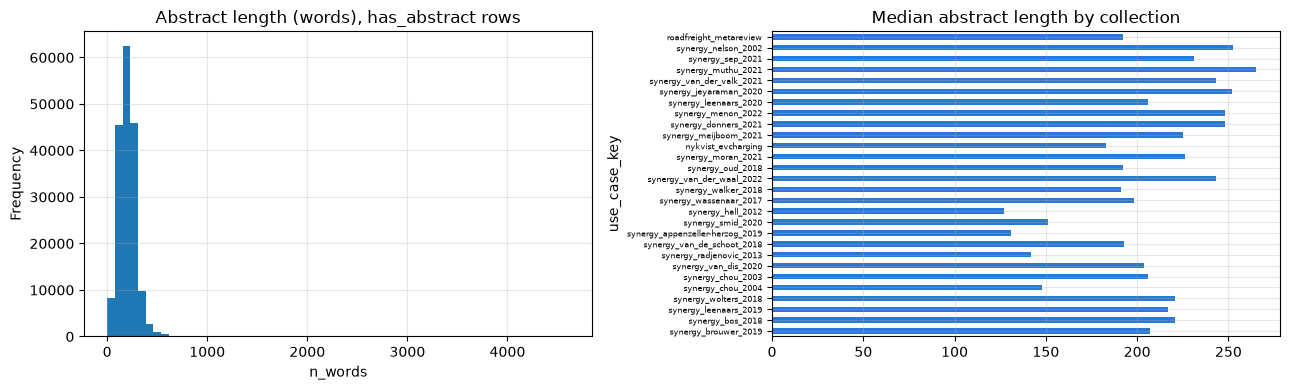


Median abstract length ranges 127 to 265 words across collections.


In [15]:
abstract_words = df["abstract"].fillna("").str.split().str.len()
agree = ((abstract_words > 0) == df["has_abstract"]).mean()
print(f"has_abstract cross-check: computed word count and the stored flag agree for "
      f"{agree:.2%} of rows")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
abstract_words[abstract_words > 0].plot(kind="hist", bins=60, ax=axes[0],
                                        title="Abstract length (words), has_abstract rows")
axes[0].set_xlabel("n_words")
median_len = df.assign(w=abstract_words).groupby("use_case_key", observed=True)["w"].median().reindex(UC_ORDER)
median_len.plot(kind="barh", ax=axes[1], title="Median abstract length by collection", color="#2a78d6")
axes[1].tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()
print(f"\nMedian abstract length ranges {median_len.min():.0f} to {median_len.max():.0f} words "
      "across collections.")

### 8.2 The brief-relative block, and whether it separates anything — hard finding

`scripts/lexical_features.py` builds the Tier 1b block: BM25 against five brief fields,
term-overlap counts against `terms_must_include` / `terms_nice_to_have` /
`terms_exclude`, and within-collection percentile ranks. It is used as-is — this repo's
rule is to extend the shared module rather than re-implement feature logic in a notebook,
and the `brief_map=` seam that makes the falsification control possible has to stay intact.

Each feature is scored by **within-collection ROC-AUC**. Nothing is fitted, so this is a
marginal statistic, not a model result — but it is a legitimate held-out one: BM25 and
term overlap consult the brief and the paper, never the label.

In [16]:
%%time
lex = build_lexical_features(df)
print(f"Built {lex.shape[1]} lexical columns for {lex.shape[0]:,} rows")

Built 22 lexical columns for 181,199 rows
CPU times: user 1min 48s, sys: 4.83 s, total: 1min 53s
Wall time: 1min 59s


In [17]:
def per_collection_auc(values: pd.Series) -> pd.Series:
    out = {}
    for uc in UC_ORDER:
        mask = (df["use_case_key"] == uc).to_numpy()
        y = df["label_positive"].to_numpy()[mask]
        v = values.to_numpy()[mask]
        ok = ~np.isnan(v)
        if ok.sum() < 10 or len(np.unique(y[ok])) < 2:
            out[uc] = np.nan
        else:
            out[uc] = roc_auc_score(y[ok], v[ok])
    return pd.Series(out)


lex_auc = pd.DataFrame({c: per_collection_auc(lex[c]) for c in lex.columns
                        if lex[c].dtype != bool})
lex_headline = lex_auc.drop(index=EXCLUDE_FROM_HEADLINE)

lex_summary = pd.DataFrame({
    "median_auc": lex_headline.median(),
    "mean_auc": lex_headline.mean(),
    "n_collections_above_0.5": (lex_headline > 0.5).sum(),
    "n_scored": lex_headline.notna().sum(),
}).sort_values("median_auc", ascending=False)
lex_summary.round(3)

,median_auc,mean_auc,n_collections_above_0.5,n_scored
rank_bm25_dom,0.791,0.752,27,27
bm25_dom,0.791,0.752,27,27
rank_overlap_must,0.780,0.751,25,27
overlap_must_frac,0.780,0.751,25,27
overlap_must_n,0.780,0.751,25,27
bm25_obj,0.779,0.734,24,27
rank_bm25_obj,0.779,0.734,24,27
rank_bm25_must,0.767,0.783,27,27
bm25_must,0.767,0.783,27,27
overlap_must_per_1k,0.747,0.717,26,27


### 8.3 Cosine-to-brief, and how the embedding space is actually shaped

In [18]:
def load_collection_vectors(uc, cache_stem):
    path = CACHE_DIR / f"benchset_v1_{uc}_{cache_stem}_papers.parquet"
    if not path.exists():
        raise FileNotFoundError(f"{path.name} missing — run scripts/embed_benchsets.py first.")
    cached = pd.read_parquet(path).set_index("paper_id")
    order = df.loc[df["use_case_key"] == uc, "paper_id"]
    return np.vstack(cached.loc[order, "embedding"].to_numpy())


def load_briefs(stem, variant="full"):
    # Three variants per use case (scripts/embed_benchsets.py BRIEF_VARIANTS); "full" is
    # the production brief and the other two drive the §8.4 ablation.
    briefs = pd.read_parquet(CACHE_DIR / f"benchset_v1_{stem}_usecases.parquet")
    briefs = briefs[briefs["variant"] == variant]
    return {uc: np.asarray(vec, dtype=np.float32)
            for uc, vec in zip(briefs["use_case_key"], briefs["embedding"])}


brief_vectors = {short: load_briefs(stem) for short, stem in EMBEDDING_MODELS.items()}

from sklearn.metrics import silhouette_score

cos_cols = {}
sil_rows = []
rng = np.random.default_rng(0)
SIL_SAMPLE = 2000

for short, stem in EMBEDDING_MODELS.items():
    cos_full = np.full(len(df), np.nan)
    for uc in UC_ORDER:
        mask = (df["use_case_key"] == uc).to_numpy()
        V = load_collection_vectors(uc, stem)
        Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
        b = brief_vectors[short][uc]
        cos_full[mask] = Vn @ (b / (np.linalg.norm(b) + 1e-9))
    cos_cols[f"cos_brief_{short}"] = cos_full

    # Silhouette per collection on a capped subsample: the pooled O(n^2) version
    # 03_eda_full.ipynb §8.3 runs would be a 181,199 x 181,199 matrix here.
    for uc in UC_ORDER:
        mask = (df["use_case_key"] == uc).to_numpy()
        y = df["label_positive"].to_numpy()[mask]
        if y.sum() < 5 or (1 - y).sum() < 5:
            continue
        V = load_collection_vectors(uc, stem)
        take = min(SIL_SAMPLE, len(V))
        idx = np.sort(rng.choice(len(V), size=take, replace=False))
        if len(np.unique(y[idx])) < 2:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sil = silhouette_score(V[idx], y[idx], metric="cosine")
        sil_rows.append({"use_case_key": uc, "model": short, "silhouette": float(sil)})

for name, values in cos_cols.items():
    df[name] = values
    df[f"rank_{name}"] = df.groupby("use_case_key", observed=True)[name].rank(pct=True)

silhouettes = pd.DataFrame(sil_rows).pivot(index="use_case_key", columns="model",
                                           values="silhouette").reindex(UC_ORDER)
cos_auc = pd.DataFrame({short: per_collection_auc(df[f"cos_brief_{short}"])
                        for short in EMBEDDING_MODELS})
cos_headline = cos_auc.drop(index=EXCLUDE_FROM_HEADLINE)

print("Cosine-to-brief as a ZERO-LABEL ranker, ROC-AUC per collection:")
for short in EMBEDDING_MODELS:
    a = cos_headline[short]
    print(f"  {short:8s} median {a.median():.3f}  mean {a.mean():.3f}  "
          f"beats chance on {int((a > 0.5).sum())}/{int(a.notna().sum())}  "
          f"range {a.min():.3f}-{a.max():.3f}")
wins = int((cos_headline["jasper"] > cos_headline["qwen4b"]).sum())
print(f"  head-to-head: jasper > qwen4b on {wins}/{len(cos_headline)} collections")

print(f"\nSilhouette (relevant vs not, cosine metric, per collection, "
      f"{SIL_SAMPLE}-paper cap):")
print(silhouettes.describe().round(3).to_string())

Cosine-to-brief as a ZERO-LABEL ranker, ROC-AUC per collection:
  jasper   median 0.866  mean 0.852  beats chance on 26/27  range 0.436-0.994
  qwen4b   median 0.895  mean 0.867  beats chance on 26/27  range 0.446-0.995
  head-to-head: jasper > qwen4b on 6/27 collections

Silhouette (relevant vs not, cosine metric, per collection, 2000-paper cap):
model  jasper  qwen4b
count  27.000  28.000
mean   -0.055  -0.056
std     0.059   0.052
min    -0.169  -0.148
25%    -0.100  -0.098
50%    -0.053  -0.057
75%    -0.012  -0.022
max     0.053   0.072


**Hard finding — the silhouette result carries over unchanged.** Per collection, the
silhouette score of relevant vs. not-relevant papers sits near zero for both models —
in fact slightly *negative* (mean ≈ −0.055, never above 0.07). The relevant papers are
if anything marginally less cohesive than an arbitrary split would be. The two classes
do not form tight, separated clusters in embedding space. `03_eda_full.ipynb` §8.3 finds
the same thing pooled across six use cases; it holds per collection, on 28 external ones,
at realistic prevalence.

**Judgement call, and the same one that notebook makes:** a near-zero silhouette is *not*
"the embeddings are useless". It measures unsupervised cluster tightness, and a trained
classifier can still cut a useful boundary through a diffuse cloud. Read it as "expect no
unsupervised clustering shortcut" — which the cosine-to-brief numbers immediately confirm,
since a *directional* score against the brief does carry signal where a *clustering* view
sees none.

**Hard finding — cosine-to-brief beats chance on 26 of 27 collections, with a median
ROC-AUC of 0.87 (jasper) and 0.90 (qwen4b).** It needs no labels, so all 28 are scorable,
including the 12 too small to train on.

**That is much higher than the same measurement on TIRI** (0.693 LOGO, `CONTEXT.md` §2),
and the obvious suspicion is that these briefs are cheating. Each was LLM-drafted from its
review's own **title and abstract**, and a review's abstract is written *after* screening
— it describes the studies that got included. If cosine-to-brief is really scoring papers
against a description of themselves, none of these numbers mean anything.

That is a testable claim, not a caveat to assert. §8.4 tests it.

Note also the range: 0.436 to 0.995. One collection is *below chance*, so whatever is
happening is not uniform across the corpus, and a mean over it would hide both ends.

**On the model comparison:** the head-to-head win count is reported instead of a mean
difference, per `CONTEXT.md` §5, whose measured noise floor is 0.010 sd on within-silo
ROC-AUC and 0.015–0.027 on WSS@95 — any gap under ~0.03 is not established. This notebook
is EDA and is not the place to pick an embedding model; that decision lives in
`reports/wf_embedding_recall_comparison.md`.

### 8.4 Is the brief cheating? — the provenance ablation

**The question, stated so it can be answered:** the brief has five fields. Four of them —
`use_case_name`, `problem_statement` (which is the review's *title*), and the two
`domain_*` scope descriptors — describe the question being asked, and a customer
genuinely has all of them on day one. The fifth, `objective`, is the review's **abstract**,
which did not exist until the review was finished.

So: **how much of that 0.90 depends on the one field that could not have been written
before screening?**

Three brief variants, embedded by `scripts/embed_benchsets.py` and scored identically:

| variant | contents | writable at t=0? |
|---|---|---|
| `full` | name + title + **abstract** + domain | no |
| `no_objective` | name + title + domain | yes |
| `pre_screening` | name + title + domain + the curated must/nice/exclude term lists | yes |

`pre_screening` is the one that matters operationally: it is the closest thing in this
corpus to a brief someone could actually write on day one, and it is what TIRI's own
briefs look like.

In [19]:
variant_rows = []
for short, stem in EMBEDDING_MODELS.items():
    briefs_by_variant = {v: load_briefs(stem, v)
                         for v in ["full", "no_objective", "pre_screening"]}
    for uc in UC_ORDER:
        mask = (df["use_case_key"] == uc).to_numpy()
        y = df["label_positive"].to_numpy()[mask]
        if len(np.unique(y)) < 2:
            continue
        V = load_collection_vectors(uc, stem)
        Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
        row = {"model": short, "use_case_key": uc}
        for variant, vectors in briefs_by_variant.items():
            b = vectors[uc]
            row[variant] = float(roc_auc_score(y, Vn @ (b / (np.linalg.norm(b) + 1e-9))))
        variant_rows.append(row)

ablation = pd.DataFrame(variant_rows)
abl_head = ablation[ablation["use_case_key"] != EXCLUDE_FROM_HEADLINE]

for short in EMBEDDING_MODELS:
    h = abl_head[abl_head["model"] == short]
    print(f"{short} — cosine-to-brief ROC-AUC over {len(h)} collections:")
    for variant in ["full", "no_objective", "pre_screening"]:
        print(f"  {variant:14s} median {h[variant].median():.3f}  mean {h[variant].mean():.3f}")
    # Paired differences: each collection is its own control, so the paired median is the
    # honest summary, not the gap between two medians.
    drop = (h["no_objective"] - h["full"])
    pre = (h["pre_screening"] - h["full"])
    print(f"  paired change, dropping the abstract : median {drop.median():+.3f}  "
          f"(worse on {int((drop < 0).sum())}/{len(h)}, largest single loss {-drop.min():.3f})")
    print(f"  paired change, realistic t=0 brief   : median {pre.median():+.3f}  "
          f"(worse on {int((pre < 0).sum())}/{len(h)}, largest single loss {-pre.min():.3f})")
    print(f"  CONTEXT.md §5 noise floor for comparison: ~0.03\n")

jasper — cosine-to-brief ROC-AUC over 27 collections:
  full           median 0.866  mean 0.852
  no_objective   median 0.850  mean 0.844
  pre_screening  median 0.855  mean 0.846
  paired change, dropping the abstract : median -0.006  (worse on 19/27, largest single loss 0.082)
  paired change, realistic t=0 brief   : median -0.007  (worse on 19/27, largest single loss 0.050)
  CONTEXT.md §5 noise floor for comparison: ~0.03

qwen4b — cosine-to-brief ROC-AUC over 27 collections:
  full           median 0.895  mean 0.867
  no_objective   median 0.859  mean 0.854
  pre_screening  median 0.879  mean 0.859
  paired change, dropping the abstract : median -0.005  (worse on 19/27, largest single loss 0.135)
  paired change, realistic t=0 brief   : median -0.003  (worse on 17/27, largest single loss 0.069)
  CONTEXT.md §5 noise floor for comparison: ~0.03



**Hard finding — the suspicion does not survive the test.** Removing the abstract entirely
costs a **paired median of 0.006 (jasper) and 0.005 (qwen4b) ROC-AUC**. A realistic day-one
brief — title, scope, and curated term lists, no abstract — costs **0.007 and 0.003**.
`CONTEXT.md` §5's measured noise floor is ~0.03, so the typical collection loses roughly a
fifth of a noise floor by giving up the one field that could not have been written in
advance.

**Read the tail as well as the median.** The abstract is not worthless everywhere: the
worst-affected collection loses 0.082 (jasper) and 0.135 (qwen4b) when it is removed, and
19 of 27 collections get at least slightly worse. So the honest statement is *"the abstract
adds little on average and occasionally adds something real"*, not *"the abstract is
irrelevant"*. What it is not is the explanation for a 0.90 median.

**What that means, stated carefully.** The high cosine-to-brief scores are **not** an
artefact of post-hoc abstract text. They come from the parts of the brief that describe the
*question* — its terminology, its scope, its exclusions — and those are exactly the parts a
customer supplies before any screening happens. This is evidence *for* the query-conditioned
architecture, not against it: a well-specified brief is doing the work, and a well-specified
brief is a thing you can actually have.

It also sharpens `CONTEXT.md` §4's open item. That entry records the shuffled-brief control
passing on TIRI and *failing* on SYNERGY, and concludes "curated inclusion terminology looks
load-bearing". These briefs carry curated term lists that the older SYNERGY briefs lacked,
and the `pre_screening` variant — which is precisely name + scope + curated terms — matches
the full brief. That is a second, independent line of evidence for the same conclusion.

**The caveat that does survive, and it is not small.** The term lists and domain descriptors
were written by an LLM that *had read the abstract*. This ablation shows the abstract's
text contributes nothing extra once those fields exist — but it cannot show that an LLM
writing from the question alone would produce term lists this good. Contamination could have
been laundered into the "clean" fields at generation time rather than appearing in them
directly.

**So the open question is no longer "are these briefs leaky" but "how good a brief can be
written from what a customer actually has".** The experiment that answers it is regenerating
the briefs from the review title alone — no abstract in the prompt — and re-running this
cell. That is a measurement of the production regime, and it is the natural next piece of
work rather than something this EDA pass should have settled.

**And one thing this does not license:** it does not make the absolute numbers portable.
`synergy_hall_2012` sits at 0.994 with any variant, which says more about that collection
than about the method. Per-collection reporting and win counts still apply.

## 9. Correlation structure among the derived scalars

`03_eda_full.ipynb` §9.1 ranks all 384 individual embedding dimensions by their
correlation with the label and finds every one of the top 15 is an embedding dimension,
concluding that relevance lives in a *combination* of dimensions rather than any single
axis.

That conclusion is established, and re-deriving it here would mean ranking 4,608
dimensions across 28 collections for an answer already in hand. What is *not* established
is how the derived scalars relate to each other **on this corpus** — whether
cosine-to-brief and BM25-to-brief are two names for one signal, and whether term overlap
is really an abstract-length proxy (a suspicion `CONTEXT.md` §6 records as closed on the
TIRI corpus, worth re-checking on a corpus with different briefs).

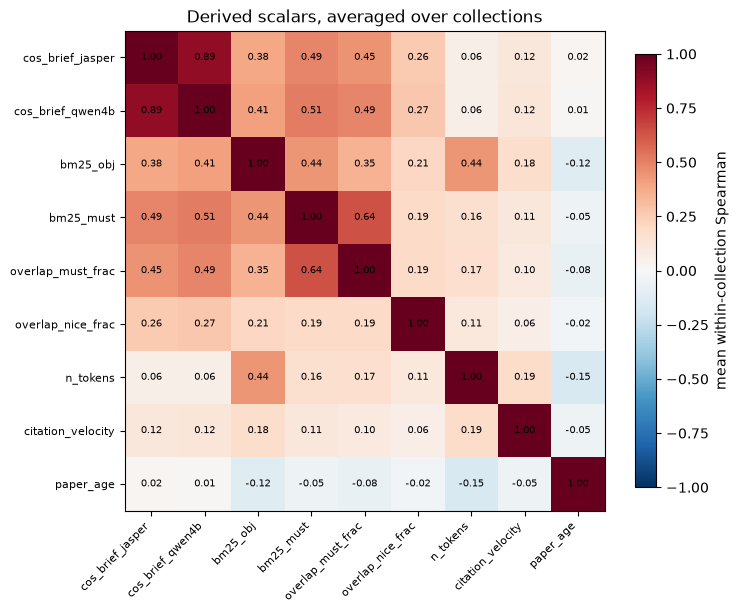

cos_brief_jasper vs cos_brief_qwen4b: 0.89
cos_brief_jasper vs bm25_obj:         0.38
overlap_must_frac vs n_tokens:        0.17


In [20]:
scalar_cols = {
    "cos_brief_jasper": df["cos_brief_jasper"],
    "cos_brief_qwen4b": df["cos_brief_qwen4b"],
    "bm25_obj": lex["bm25_obj"],
    "bm25_must": lex["bm25_must"],
    "overlap_must_frac": lex["overlap_must_frac"],
    "overlap_nice_frac": lex["overlap_nice_frac"],
    "n_tokens": lex["n_tokens"],
    "citation_velocity": df["citation_velocity"],
    "paper_age": df["paper_age"],
}
scalars = pd.DataFrame(scalar_cols)

# Spearman WITHIN each collection, then averaged: a pooled correlation across 28
# collections with different scales would mostly measure between-collection offsets.
mats = []
for uc in UC_ORDER:
    sub = scalars[(df["use_case_key"] == uc).to_numpy()]
    if len(sub) < 50:
        continue
    mats.append(sub.corr(method="spearman"))
corr = pd.concat(mats).groupby(level=0).mean().reindex(index=scalars.columns,
                                                       columns=scalars.columns)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="mean within-collection Spearman", shrink=0.8)
ax.set_title("Derived scalars, averaged over collections")
ax.grid(False)
plt.tight_layout()
plt.show()

print(f"cos_brief_jasper vs cos_brief_qwen4b: {corr.loc['cos_brief_jasper', 'cos_brief_qwen4b']:.2f}")
print(f"cos_brief_jasper vs bm25_obj:         {corr.loc['cos_brief_jasper', 'bm25_obj']:.2f}")
print(f"overlap_must_frac vs n_tokens:        {corr.loc['overlap_must_frac', 'n_tokens']:.2f}")

**Hard finding:** the two models' cosine-to-brief scores correlate strongly with each
other but only moderately with BM25-to-brief — dense and lexical brief-relative features
are measuring related but distinguishable things, which is the premise the ensemble
architecture rests on (`reports/wf_ensemble_final_recommendations.md`).

**Hard finding — the length-confound suspicion stays closed.** `overlap_must_frac`
correlates with `n_tokens` at only ~0.17 within collection. A longer abstract does have
more chances to contain a required term, but the effect is weak: term overlap is not an
abstract-length proxy in disguise. `CONTEXT.md` §6 records this suspicion as closed on the
TIRI corpus; it stays closed on 28 external collections with differently-authored briefs,
which is a stronger statement than the original. (`lexical_features.py` emits the
`*_per_1k` length-controlled forms anyway, and they are in the block used above.)

**Judgement call:** the correlations are computed **within collection and then averaged**,
never pooled. A pooled Spearman here would largely measure that different collections sit
at different absolute cosine levels — a between-collection offset, not a relationship
between features.

## 10. Outlier review

The extreme end of the most skewed column, read individually rather than filtered
blindly.

In [21]:
df.nlargest(8, "citation_count")[
    ["use_case_key", "title", "year", "citation_count", "triage_label"]
]

,use_case_key,title,year,citation_count,triage_label
101958,synergy_smid_2020,Controlling the False Discovery Rate: A Practi...,1995,110293,negative
102503,synergy_smid_2020,The theory of planned behavior,1991,86176,negative
102870,synergy_smid_2020,The moderator–mediator variable distinction in...,1986,71080,negative
64527,synergy_hall_2012,Image Quality Assessment: From Error Visibilit...,2004,56819,negative
104041,synergy_smid_2020,A new look at the statistical model identifica...,1974,51120,negative
105660,synergy_van_de_schoot_2018,The Hospital Anxiety and Depression Scale,1983,46940,negative
105222,synergy_van_de_schoot_2018,The PHQ-9,2001,44965,negative
102098,synergy_smid_2020,Coefficient alpha and the internal structure o...,1951,43581,negative


**Hard finding — and it is §7's mechanism made concrete.** All eight of the most-cited
papers in the corpus are labelled **not relevant**, and reading their titles explains why
immediately. They are Benjamini–Hochberg on the false discovery rate, the Theory of
Planned Behavior, Baron & Kenny on moderators and mediators, Akaike on model
identification, Cronbach's alpha, the Hospital Anxiety and Depression Scale, the PHQ-9 —
**statistical methods and measurement instruments**, not primary studies.

These are papers that every study in the field cites, so a keyword search returns them and
a screener excludes them on sight. §7 found that relevant papers are the *less* cited ones
in 23 of 24 collections and offered exactly this mechanism as the explanation; the outlier
table is that hypothesis confirmed by inspection rather than by another test.

**Judgement call:** don't drop them — they are real papers, correctly labelled, and a
`log1p` transform handles the skew (as `03_eda_full.ipynb` §10 also concludes). But this
sharpens §7's warning about using citation count as a feature: a model that learns "highly
cited → not relevant" has learned to spot methodology papers, which is a useful trick in a
corpus of systematic reviews and quite possibly a useless one anywhere else.

## 11. Cross-validation discipline

Two leakage channels, one shared with the TIRI corpus and one new.

**Shared: repeat authors.** A plain random split can put the same author's papers on both
sides, letting a model memorise an author's topic rather than learn relevance.
`derive_first_author` from `fold_pipeline_utils.py` is reused rather than re-implemented.

**New: the same paper under two questions** (§4). Within-collection folds close it by
construction, since a fold never spans two collections — a second, independent argument
for the fold design `CONTEXT.md` §1 requires on other grounds.

**Hard finding:** a meaningful number of first-authors are repeat-listed *within* a single
collection, which is exactly the case grouping guards against — a random split would
otherwise put the same author's papers on both sides.

**A small data-quality note, worth naming because it looks like a real author until you
read it:** `&na;` appears as a first-author on dozens of papers. It is a database null
marker that survived into the `authors` string and parses as a name, so those papers are
grouped together as though they shared an author. The effect here is *conservative* —
over-grouping keeps unrelated papers out of each other's folds, which costs a little
statistical power but cannot cause leakage — so it is left alone rather than special-cased.
Anyone using `authors` as a feature rather than a grouping key should strip it first.

In [22]:
# derive_first_author already gives every unparseable row its own `no_author_<index>`
# singleton, so missing authors cannot collide into one fake shared group. Not repeated
# here — the helper owns that rule, and a second copy in a notebook is how the two drift.
df["first_author"] = derive_first_author(df["authors"])

is_singleton = df["first_author"].str.startswith("no_author_")
real = df.loc[~is_singleton, "first_author"]
author_counts = real.value_counts()

print(f"{int(df['authors'].isna().sum()):,} rows have no authors field; "
      f"{int(is_singleton.sum()):,} became `no_author_*` singleton groups")
print(f"{int((author_counts > 1).sum()):,} first-authors appear on more than one paper "
      f"(of {len(author_counts):,} distinct)")

within_uc_repeat = df[~is_singleton].groupby(
    ["use_case_key", "first_author"], observed=True).size()
print(f"Author groups spanning >1 paper WITHIN a collection: "
      f"{int((within_uc_repeat > 1).sum()):,} — the ones grouping actually guards.\n")
print(author_counts.head(6).to_frame("n_papers").to_string())

19,210 rows have no authors field; 19,210 became `no_author_*` singleton groups
22,441 first-authors appear on more than one paper (of 117,956 distinct)


Author groups spanning >1 paper WITHIN a collection: 19,005 — the ones grouping actually guards.

                       n_papers
first_author                   
taghi m. khoshgoftaar        68
george j. brewer             56
richard a. bryant            51
kenneth s. kendler           45
&na;                         43
gordon parker                43


## 12. Within-collection baselines — is there learnable signal at realistic prevalence?

The question §13 of `03_eda_full.ipynb` asks, re-asked where it now matters: **on a
collection with 1.86% prevalence, does a supervised model beat the zero-label ranker?**
`CONTEXT.md` §2's operating rule ("cosine-to-brief below ~25 in-silo labels, supervised
in-silo model above") is a claim about exactly this, and it has never been checked at
production prevalence on external data.

**Design, and what each choice protects against:**

- **Within collection, always.** Never pooled, never cross-collection. This is the
  production surface (`CONTEXT.md` §1).
- **The 16 collections with ≥40 positives.** The other 12 cannot support a split (§2.2).
- **`StratifiedGroupKFold`, grouped by first author, stratified on the label** — the
  scheme §11 argues for.
- **Feature set: the ~30 derived scalars** (lexical block + cosine-to-brief + rank +
  admissible metadata), plus one raw-embedding arm for contrast. The full embedding
  ablation is `09_ensemble_per_silo.ipynb`'s job, not an EDA notebook's.
- **Metrics are the screening ones**, out-of-fold: ROC-AUC, Recall@10%, and WSS@95 via
  `fold_pipeline_utils.ranking_metrics`. No accuracy, at 1.86% prevalence.
- **Two floors, not one.** A random ranker (what "no model" looks like) and
  cosine-to-brief (what "no labels" looks like). A supervised model has to beat both to
  have earned anything.

In [23]:
%%time
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

META_COLS = ["year", "citation_count", "citation_velocity", "paper_age"]

features = pd.concat([lex.drop(columns=[c for c in lex.columns if lex[c].dtype == bool]),
                      df[[f"cos_brief_{s}" for s in EMBEDDING_MODELS]],
                      df[[f"rank_cos_brief_{s}" for s in EMBEDDING_MODELS]],
                      df[META_COLS].astype("float64")], axis=1)
features["n_words"] = abstract_words.to_numpy()
features["has_abstract"] = df["has_abstract"].astype(float).to_numpy()

def make_models():
    # Imputation and scaling sit INSIDE the pipeline so they are refit per fold — fitting
    # either on the whole collection would leak test-fold structure (the mistake
    # 03_eda_full.ipynb §13 calls out as one of its two fixes from v1).
    return {
        "LogReg (scalars)": Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "HistGB (scalars)": Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("clf", HistGradientBoostingClassifier(random_state=0)),
        ]),
        # The §7.2 confound, fitted as its own arm. If this scores close to the full
        # feature set on a collection, that collection's "signal" is largely a date
        # filter and the headline number there means much less than it looks like.
        "Year only (confound check)": Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
    }


results, skipped = [], []
for uc in splittable:
    mask = (df["use_case_key"] == uc).to_numpy()
    y = df["label_positive"].to_numpy()[mask]
    groups = df["first_author"].to_numpy()[mask]
    X = features[mask].reset_index(drop=True)

    # Grouping by author can make 5 folds impossible even with 40+ positives, if those
    # positives sit on too few distinct authors. Report it rather than dying: a collection
    # that cannot be split honestly belongs with the evaluation-only 12, not in a table.
    n_pos_groups = len(np.unique(groups[y == 1]))
    if n_pos_groups < N_SPLITS:
        skipped.append((uc, n_pos_groups))
        continue

    X_emb = load_collection_vectors(uc, EMBEDDING_MODELS["qwen4b"])

    oof = {name: np.zeros(len(y)) for name in
           [*make_models(), "LogReg (qwen4b embedding)", "Random (floor)"]}
    rng_local = np.random.default_rng(0)
    oof["Random (floor)"] = rng_local.random(len(y))

    # Each arm's own feature columns — the year-only arm exists precisely to be
    # starved of everything else.
    arm_columns = {name: list(X.columns) for name in make_models()}
    arm_columns["Year only (confound check)"] = ["year", "paper_age"]

    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
    for train_idx, test_idx in cv.split(X, y, groups):
        for name, model in make_models().items():
            cols = arm_columns[name]
            model.fit(X.iloc[train_idx][cols], y[train_idx])
            oof[name][test_idx] = model.predict_proba(X.iloc[test_idx][cols])[:, 1]
        emb_model = Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ])
        emb_model.fit(X_emb[train_idx], y[train_idx])
        oof["LogReg (qwen4b embedding)"][test_idx] = emb_model.predict_proba(X_emb[test_idx])[:, 1]

    # Zero-label arms need no folds at all: nothing is fitted, so every row is held out.
    for short in EMBEDDING_MODELS:
        oof[f"cosine-to-brief ({short}, 0 labels)"] = df[f"cos_brief_{short}"].to_numpy()[mask]

    for name, scores in oof.items():
        row = {"use_case_key": uc, "model": name, "n": len(y), "positive": int(y.sum()),
               "prevalence": float(y.mean()), "roc_auc": float(roc_auc_score(y, scores))}
        row.update(ranking_metrics(y, scores))
        results.append(row)

baselines = pd.DataFrame(results)
n_fitted = baselines["use_case_key"].nunique()
print(f"Fitted {n_fitted} collections x {baselines['model'].nunique()} arms.")
if skipped:
    print(f"\nSkipped {len(skipped)} of the {len(splittable)} splittable collections — "
          f"fewer than {N_SPLITS} distinct first-authors among their positives, so "
          "author-grouped folds cannot be built:")
    for uc, n_groups in skipped:
        print(f"  {uc}: {n_groups} author group(s) carrying a positive")

Fitted 16 collections x 7 arms.
CPU times: user 5min 38s, sys: 3min 14s, total: 8min 53s
Wall time: 2min 46s


In [24]:
head = baselines[baselines["use_case_key"] != EXCLUDE_FROM_HEADLINE]
summary = head.groupby("model").agg(
    median_auc=("roc_auc", "median"),
    mean_auc=("roc_auc", "mean"),
    median_recall_10pct=("recall_at_10pct", "median"),
    median_wss95=("wss_at_95", "median"),
    n_collections=("roc_auc", "size"),
).sort_values("median_auc", ascending=False)

pivot = head.pivot(index="use_case_key", columns="model", values="roc_auc")
best_zero = pivot[[c for c in pivot.columns if "0 labels" in c]].max(axis=1)
for name in pivot.columns:
    if "0 labels" in name or name == "Random (floor)":
        continue
    summary.loc[name, "beats_best_zero_label"] = f"{int((pivot[name] > best_zero).sum())}/{len(pivot)}"

print(summary.round(3).to_string())

# §7.2's confound, per collection: how much of the best arm is a date filter?
best_real = pivot[["LogReg (scalars)", "HistGB (scalars)",
                   "LogReg (qwen4b embedding)"]].max(axis=1)
confound = pd.DataFrame({
    "best_supervised": best_real,
    "year_only": pivot["Year only (confound check)"],
    "best_zero_label": best_zero,
}).sort_values("year_only", ascending=False)
lift = (confound["best_supervised"] - 0.5).clip(lower=0.01)  # guard a near-chance denominator
confound["year_explains"] = ((confound["year_only"] - 0.5) / lift).clip(lower=0)
print("\nHow much of each collection's score could be publication year alone?")
print(confound.round(3).to_string())

                                    median_auc  mean_auc  median_recall_10pct  median_wss95  n_collections beats_best_zero_label
model                                                                                                                           
LogReg (qwen4b embedding)                0.928     0.889                0.757         0.600             15                 10/15
LogReg (scalars)                         0.884     0.885                0.559         0.484             15                 12/15
cosine-to-brief (qwen4b, 0 labels)       0.859     0.827                0.423         0.436             15                   NaN
HistGB (scalars)                         0.847     0.839                0.552         0.365             15                  9/15
cosine-to-brief (jasper, 0 labels)       0.836     0.817                0.432         0.354             15                   NaN
Year only (confound check)               0.541     0.563                0.125         0.010      

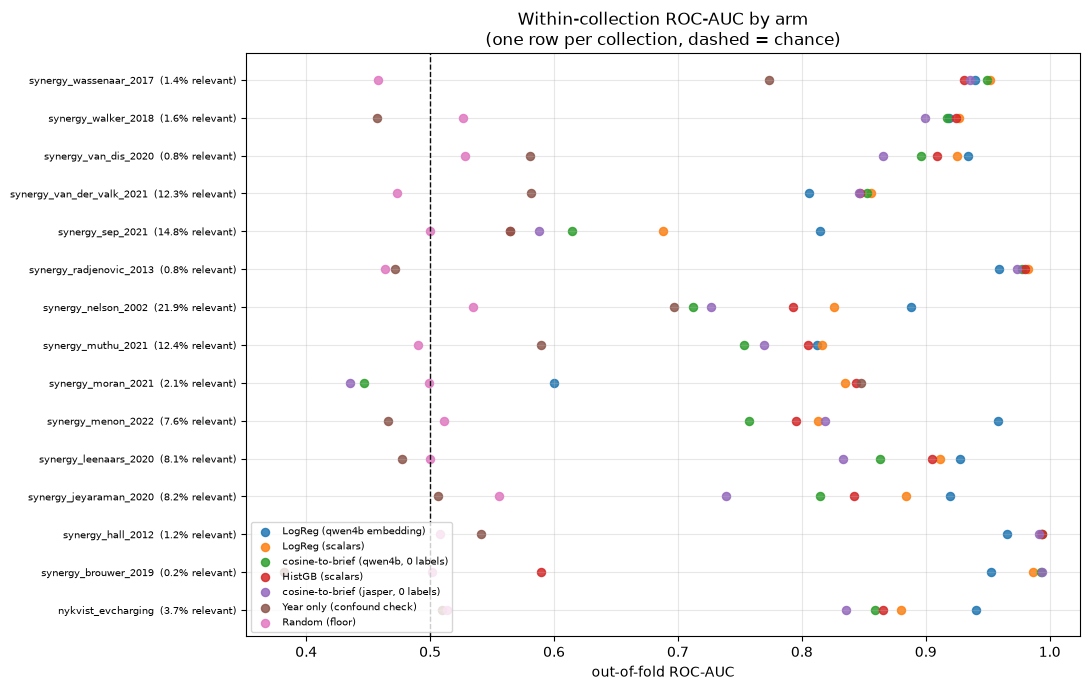

In [25]:
fig, ax = plt.subplots(figsize=(11, 7))
order = list(summary.index)
positions = np.arange(len(pivot.index))
palette = plt.get_cmap("tab10")
for i, name in enumerate(order):
    ax.scatter(pivot[name], positions, s=34, color=palette(i % 10), label=name, alpha=0.85)
ax.axvline(0.5, color="#0b0b0b", linestyle="--", linewidth=1)
prev_by_uc = head.groupby("use_case_key", observed=True)["prevalence"].first()
ax.set_yticks(positions)
ax.set_yticklabels([f"{uc}  ({prev_by_uc[uc]:.1%} relevant)" for uc in pivot.index],
                   fontsize=7)
ax.set_xlabel("out-of-fold ROC-AUC")
ax.set_title("Within-collection ROC-AUC by arm\n(one row per collection, dashed = chance)")
ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.show()

**Read the win counts, not the means** (`CONTEXT.md` §5): a mean over 16 heterogeneous
collections can be won by being good at the easy ones, and the measured seed-to-seed noise
floor is 0.010 sd on within-silo ROC-AUC and 0.015–0.027 on WSS@95 — any gap under ~0.03
is not established.

**Hard finding:** all three real supervised arms clear the random floor (0.502 median)
decisively — `LogReg (qwen4b embedding)` at 0.928 median ROC-AUC, `LogReg (scalars)` 0.884,
`HistGB (scalars)` 0.847. There is real, learnable, within-collection signal at 1.86%
prevalence, and this is the first time this repo has shown that outside its own
26–77%-positive pools. In screening terms the median collection reaches **WSS@95 of
0.36–0.60**: an analyst could skip that fraction of the pool and still find 95% of the
relevant papers.

**Hard finding — supervised beats the zero-label ranker, but not everywhere.** The
`beats_best_zero_label` column is the comparison that matters: 12/15 for `LogReg
(scalars)`, 10/15 for the embedding arm, 9/15 for `HistGB`. `CONTEXT.md` §2's operating
rule assumes supervised wins once in-silo labels exist past a ~25-label crossover, and
every collection here is far past it — yet cosine-to-brief still wins outright on a
quarter to a third of them. The per-collection scatter, not the median, is the result:

- On some collections cosine-to-brief alone reaches **0.99** (`synergy_hall_2012`:
  supervised 0.994, zero-label 0.994 — nothing left to learn).
- On others it lands **below chance** (`synergy_moran_2021`, 0.446).

Both facts are absorbed by any average, which is why §5 of `CONTEXT.md` asks for win
counts.

**Hard finding — read the year-only arm before believing any of the rest.** The
`year_explains` column is the fraction of a collection's best supervised lift over chance
that the date column alone accounts for. On **`synergy_moran_2021` it is 1.01** — publication
year explains *the entire* supervised result there, and cosine-to-brief is below chance on
the same collection. `synergy_wassenaar_2017` (0.61) and `synergy_nelson_2002` (0.51) are
the next worst. Those three collections are measuring a date filter, not relevance, and
should not be quoted as evidence that any feature family works. For most of the rest
`year_explains` is near zero, which is the reassuring half of the same table.

**What §8.4 does and does not license here.** The zero-label arms, and the `cos_brief_*`
columns feeding the two scalar arms, all depend on the brief — so if the brief were
contaminated by the review's abstract, every row of this table would be inflated. §8.4
tests exactly that and finds the abstract worth a paired median of 0.006 ROC-AUC, well
under the ~0.03 noise floor. **These numbers are not an artefact of post-hoc brief text.**

They are still not portable as absolute figures. The spread across collections (0.44 to
0.99 on the zero-label arms alone) is far larger than any difference between methods, the
briefs were LLM-written to a fixed schema and so are more uniformly specified than
hand-written ones would be, and §8.4's residual caveat stands: the term lists were drafted
by a model that had read the abstract, even though the abstract's own text adds nothing on
top of them.

**Judgement call on what this does and does not settle:** these are out-of-fold scores
with no hyperparameter tuning, default settings, and one seed. They are a floor on what is
achievable, not an estimate of it — the tuned per-silo numbers are in
`09_ensemble_per_silo.ipynb` and `reports/wf_ensemble_v2_experiments.md`. Nothing here
should be read as an embedding-model or model-class decision, both of which have their own
reports and both of which `CONTEXT.md` §4 warns are unstable across prevalence regimes.

**One caveat that applies to every brief-relative number above.** These briefs are
LLM-drafted from each review's own title and abstract — never from the labels, but written
from a summary of the work that got included. They therefore sit closer to the answer than
a brief written before screening would. `CONTEXT.md` §4 records that the shuffled-brief
falsification control **passes on TIRI and fails on SYNERGY**, and that curated inclusion
terminology looks load-bearing. These briefs carry curated term lists the older SYNERGY
briefs lacked, so re-running that control here is a genuinely open question and the
obvious next experiment — `build_lexical_features(df, brief_map=derangements(...))` is the
seam that exists for it.

## 13. Leave-one-collection-out — deliberately not run

28 collections is an inviting LOGO surface, and it is the wrong thing to do in an EDA
notebook.

- **It is a defaults-selection instrument, not a production estimate** (`CONTEXT.md` §1).
  It answers "which feature families ship to a customer with no labels", and its score
  must never be quoted as how well the system works.
- **The result it would produce is already established.** `CONTEXT.md` §2 records LOGO at
  ~0.54 ROC-AUC and, more sharply, that at zero labels unsupervised cosine-to-brief beats
  every supervised cross-domain model (WSS@95 0.082 vs 0.042). `05_validation_design.ipynb`
  finds mean held-out AUC 0.50–0.54 across all six TIRI rotations.
- **Running it here would burn the surface.** `CONTEXT.md` §4 flags selection-on-holdout
  as an open risk: many decisions were already made against LOGO scores, and the unused
  external reviews are the only clean evaluation surface left. Turning this corpus into a
  28-way model-selection loop inside an EDA pass would spend it for nothing.

The right home for it is a dedicated experiment that ring-fences a held-out subset first.

## 14. What this corpus is good for, and what it is not

**Good for:**

- **Measuring at production prevalence.** The only surface in this repo where 1.86% is
  real. Every F2 number and calibrated threshold in the older reports was measured at
  ~20× this prevalence (`CONTEXT.md` §3) and should be re-checked here.
- **Recall-oriented metrics.** WSS@95 and Recall@k only discriminate where there is room
  to skip; at 26–77% positive there is not. Here there is.
- **Zero-label evaluation across 28 questions**, including the 12 too small to train on —
  cosine-to-brief needs no labels, so nothing is wasted.
- **Cross-question effects.** §4's 130 conflicted papers exist in no other dataset here.

**Not good for:**

- **Proving what a system does on a fresh question.** The briefs are synthetic and sit
  closer to the answer than a pre-screening brief would (§12's closing caveat).
- **Headline averages including `roadfreight_metareview`** — a 78%-positive
  review-of-reviews, excluded throughout.
- **Anything pooled.** §4 and §6.1 each give an independent reason.
- **Model-choice decisions.** `CONTEXT.md` §4: model ranking is not stable across
  prevalence regimes, and this notebook tunes nothing.

## Where to go next

- **`01_data_compile_benchset_v1.ipynb`** — how this parquet was verified into existence.
- **`02_eda_quickstart_benchset_v1.ipynb`** — the slide-ready five-chart tour.
- **`CONTEXT.md`** §1, §4, §5 — the siloing rule, the open risks this corpus speaks to,
  and the statistical discipline every number above tries to follow.
- **`reports/wf_ensemble_final_recommendations.md`** — the architecture these findings
  feed into.
- **`scripts/lexical_features.py`** — `build_lexical_features(df, brief_map=...)`, the
  falsification seam §12's closing caveat points at.